In [1]:
import h5py 
import dxchange
import os
import numpy as np
from holotomocupy.utils import *

astropy module not found
olefile module not found


## Parameters

In [2]:
n = 2048
ntheta = 1800
detector_pixelsize = 1.4760147601476e-6 * 2
energy = 33.35
wavelength = 1.24e-09 / energy
focustodetectordistance = 1.2889995

sx0 = 1.28e-3
z1 = np.array([7.393, 7.655, 8.704, 10.882]) * 1e-3 - sx0
ndist = len(z1)
z2 = focustodetectordistance - z1

distances = (z1 * z2) / focustodetectordistance
magnifications = focustodetectordistance / z1
norm_magnifications = magnifications / magnifications[0]
voxelsizes = np.abs(detector_pixelsize / magnifications)
voxelsize = voxelsizes[0]

path = '/data2/vnikitin/atomium/20250607/AtomiumL1//'
pfile = 'AtomiumL1_HT_014nm'
path_out = '/data2/vnikitin/atomium_rec/20250607/AtomiumL1/'
file_out = f'data.h5'

print(magnifications)
#1009.624036


[210.86201538 202.196      173.62601024 134.242814  ]


In [3]:
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar

import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],  # fallbacks
})

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",   # Times-like math
    # optional:
    # "mathtext.default": "regular",
})
def mshow(a, show=False, **args):
    if show:
        if isinstance(a, cp.ndarray):
            a = a.get()
        fig, axs = plt.subplots(1, 1, figsize=(6,6))
        im = axs.imshow(a, cmap="gray", **args)
        cbar = fig.colorbar(im, fraction=0.046, pad=0.04)
        scalebar = ScaleBar(14e-3, "um", length_fraction=0.25, font_properties={
            "family": "serif", 
        },  # For more information, see the cell below                
        location="lower right")
        cbar.ax.tick_params(labelsize=28)
        axs.add_artist(scalebar)
        # plt.show()


### Parse files and save everything to h5

In [4]:
import numpy as np
import tifffile
from holotomocupy.utils import *


In [5]:
mpl.rcParams['font.size'] = 24  # optional
mpl.rcParams["xtick.labelsize"] = 16
mpl.rcParams["ytick.labelsize"] = 16
def mshow(a, show=False, **args):
    if show:
        if isinstance(a, cp.ndarray):
            a = a.get()
        fig, axs = plt.subplots(1, 1, figsize=(6,6))
        im = axs.imshow(a, cmap="gray", **args)
        # cbar = fig.colorbar(im, fraction=0.046, pad=0.1,orientation="horizontal", location="bottom")
        scalebar = ScaleBar(14e-3, "um", length_fraction=0.25, font_properties={
            "family": "serif",
        },  # For more information, see the cell below                
        location="lower right")
        # cbar.ax.tick_params(labelsize=20)
        # axs.axis('off')
        axs.add_artist(scalebar)
        
        # plt.show()
def find_min_max(data):
    """Find min and max values according to histogram"""

    h, e = np.histogram(data[:], 1000)
    stend = np.where(h > np.max(h)*0.03)
    st = stend[0][0]
    end = stend[0][-1]
    mmin = e[st]
    mmax = e[end+1]

    return mmin, mmax

In [6]:
# ss

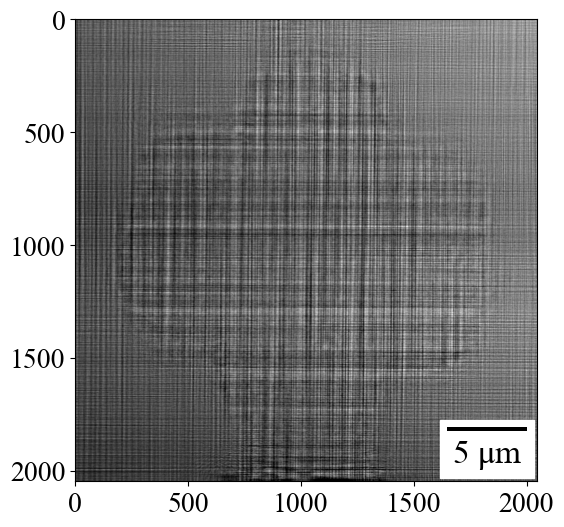

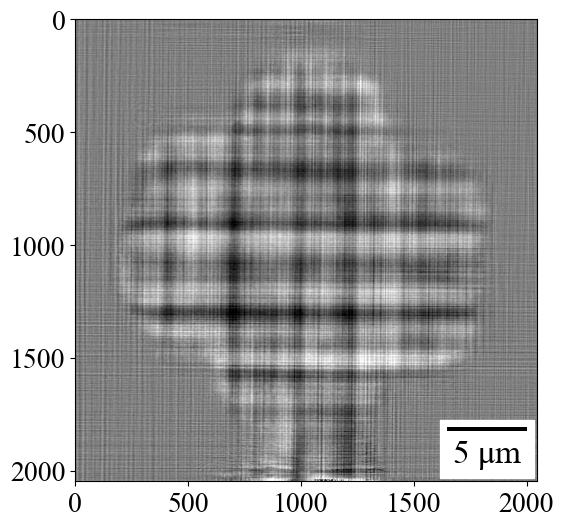

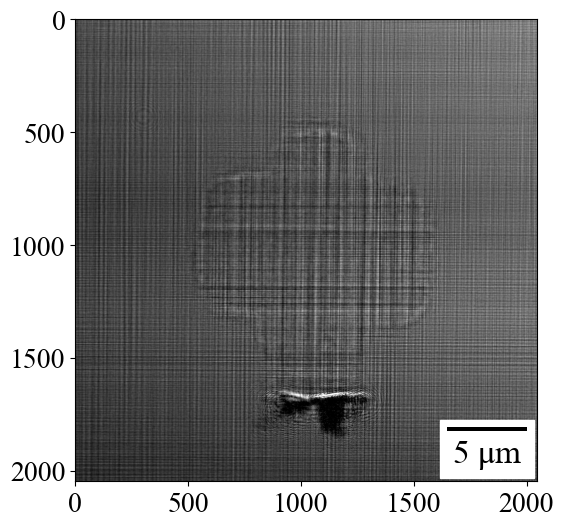

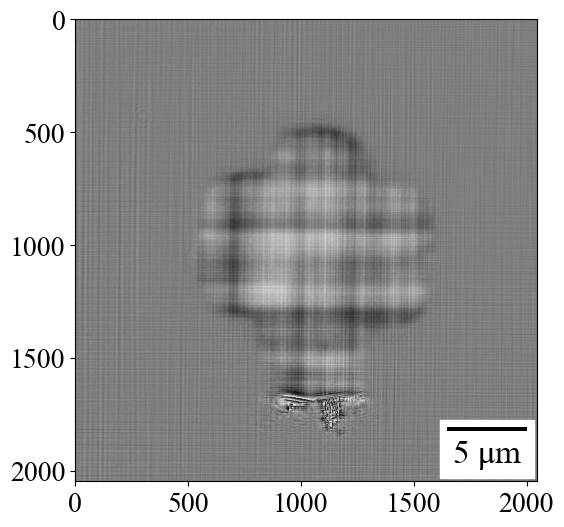

In [ ]:
mpl.rcParams['font.size'] = 24  # optional
mpl.rcParams["xtick.labelsize"] = 20
mpl.rcParams["ytick.labelsize"] = 20
iter=96
prb_abs = tifffile.imread(f'/data2/vnikitin/atomium_rec/20250607/AtomiumL1/runt1/0/rec_prb_abs0/{iter:04}.tiff')
prb_angle = tifffile.imread(f'/data2/vnikitin/atomium_rec/20250607/AtomiumL1/runt1/0/rec_prb_angle0/{iter:04}.tiff')
mshow(prb_abs,True,vmax=6000,vmin=1000)
plt.savefig(f"figs/prbabs0.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
mshow(prb_angle,True,vmax=1.2,vmin=-1.2)
plt.savefig(f"figs/prbangle0.png", dpi=300, bbox_inches="tight", pad_inches=0.02)


prb_abs = tifffile.imread(f'/data2/vnikitin/atomium_rec/20250607/AtomiumL1/runt1/0/rec_prb_abs3/{iter:04}.tiff')
prb_angle = tifffile.imread(f'/data2/vnikitin/atomium_rec/20250607/AtomiumL1/runt1/0/rec_prb_angle3/{iter:04}.tiff')
mshow(prb_abs,True,vmax=7000,vmin=1000)
plt.savefig(f"figs/prbabs3.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
mshow(prb_angle,True,vmax=2.4,vmin=-2.4)
plt.savefig(f"figs/prbangle3.png", dpi=300, bbox_inches="tight", pad_inches=0.02)


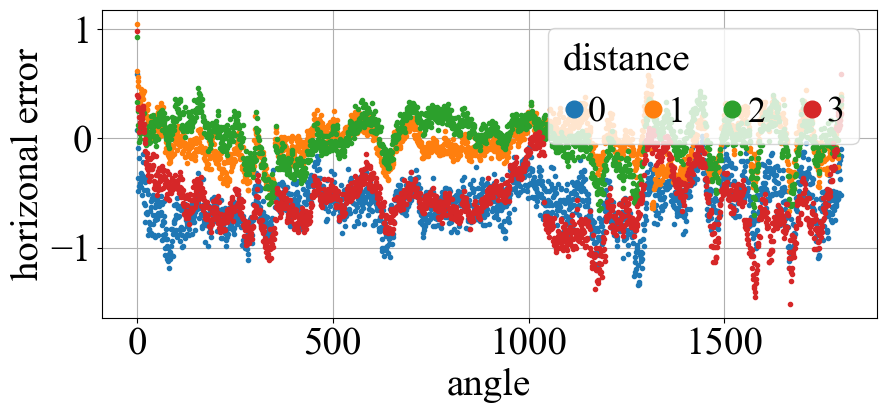

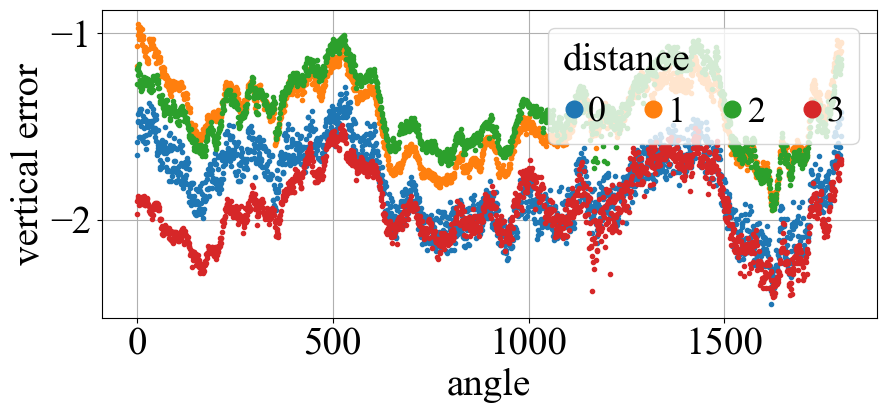

In [17]:
mpl.rcParams['font.size'] = 28  # optional
mpl.rcParams["xtick.labelsize"] = 28
mpl.rcParams["ytick.labelsize"] = 28
ndist = 4
rpos = np.load(f'/data2/vnikitin/atomium_rec/20250607/AtomiumL1/runt1/0/pos{iter:04}.npy')
with h5py.File(f'{path_out}/data.h5') as fid:                
        pos = (fid[f'/exchange/cshifts_final'][:]).astype('float32')
rotation_center_shift = -14.66
rpos[:,:,1]-=rotation_center_shift
err = pos-rpos
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
l=ax.plot(err[:,:,1], ".")
ax.set_xlabel('angle')
ax.set_ylabel('horizonal error')
labels = ["0", "1", "2", "3"]
leg = ax.legend(l, labels, title="distance",ncol=len(labels),loc='upper right',columnspacing=1,
    handletextpad=0.1,handlelength=0.6,fontsize=26,markerscale=4.0)
leg._legend_box.align = "left"
# ax[1].plot(err[::2,:,0], ".")
# ax[1].set_title("y")
# ax[0].grid()
ax.grid()
plt.savefig(f"figs/errx.png", dpi=300, bbox_inches="tight", pad_inches=0.02)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
l=ax.plot(err[:,:,0], ".")
ax.set_xlabel('angle')
ax.set_ylabel('vertical error')
labels = ["0", "1", "2", "3"]
leg = ax.legend(l, labels, title="distance",ncol=len(labels),loc='upper right',columnspacing=1,
    handletextpad=0.1,handlelength=0.6,fontsize=26,markerscale=4.0)
leg._legend_box.align = "left"
# plt.legend(markerscale=2.0)   # legend markers 2× larger
# ax[1].plot(err[::2,:,0], ".")
# ax[1].set_title("y")
# ax[0].grid()
ax.grid()
plt.savefig(f"figs/erry.png", dpi=300, bbox_inches="tight", pad_inches=0.02)


In [ ]:
ss = 1024
bb=mrec[nz//2-ss:nz//2+ss,ny//2-ss:ny//2+ss,nx//2-ss:nx//2+ss]
aa=prec[nz//2-ss:nz//2+ss,ny//2-ss:ny//2+ss,nx//2-ss:nx//2+ss]

aa = (aa-mmin1)/(mmax1-mmin1)
bb = (bb-mmin2)/(mmax2-mmin2)
aa[aa<0] = 0
aa[aa>1] = 1
bb[bb<0] = 0
bb[bb>1] = 1


In [ ]:
mpl.rcParams['font.size'] = 24  # optional
mpl.rcParams["xtick.labelsize"] = 20
mpl.rcParams["ytick.labelsize"] = 20
iter=64+16
prb_abs = tifffile.imread(f'/data2//vnikitin/brain_rec/20251115/Y350a1234/4500_2048_0_0.0_0.003_0.05_0.02_20_1.1_0/rec_prb_abs0/{iter:04}.tiff')
prb_angle = tifffile.imread(f'/data2//vnikitin/brain_rec/20251115/Y350a1234/4500_2048_0_0.0_0.003_0.05_0.02_20_1.1_0/rec_prb_angle0/{iter:04}.tiff')
mshow(prb_abs*5000,True,vmax=7000,vmin=1000)
plt.savefig(f"figs/prbabs0.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
mshow(prb_angle,True,vmax=2.4,vmin=-2.4)
plt.savefig(f"figs/prbangle0.png", dpi=300, bbox_inches="tight", pad_inches=0.02)


prb_abs = tifffile.imread(f'/data2//vnikitin/brain_rec/20251115/Y350a1234/4500_2048_0_0.0_0.003_0.05_0.02_20_1.1_0/rec_prb_abs3/{iter:04}.tiff')
prb_angle = tifffile.imread(f'/data2//vnikitin/brain_rec/20251115/Y350a1234/4500_2048_0_0.0_0.003_0.05_0.02_20_1.1_0/rec_prb_angle3/{iter:04}.tiff')
mshow(prb_abs*5000,True,vmax=7000,vmin=1000)
plt.savefig(f"figs/prbabs3.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
mshow(prb_angle,True,vmax=2.4,vmin=-2.4)
plt.savefig(f"figs/prbangle3.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
